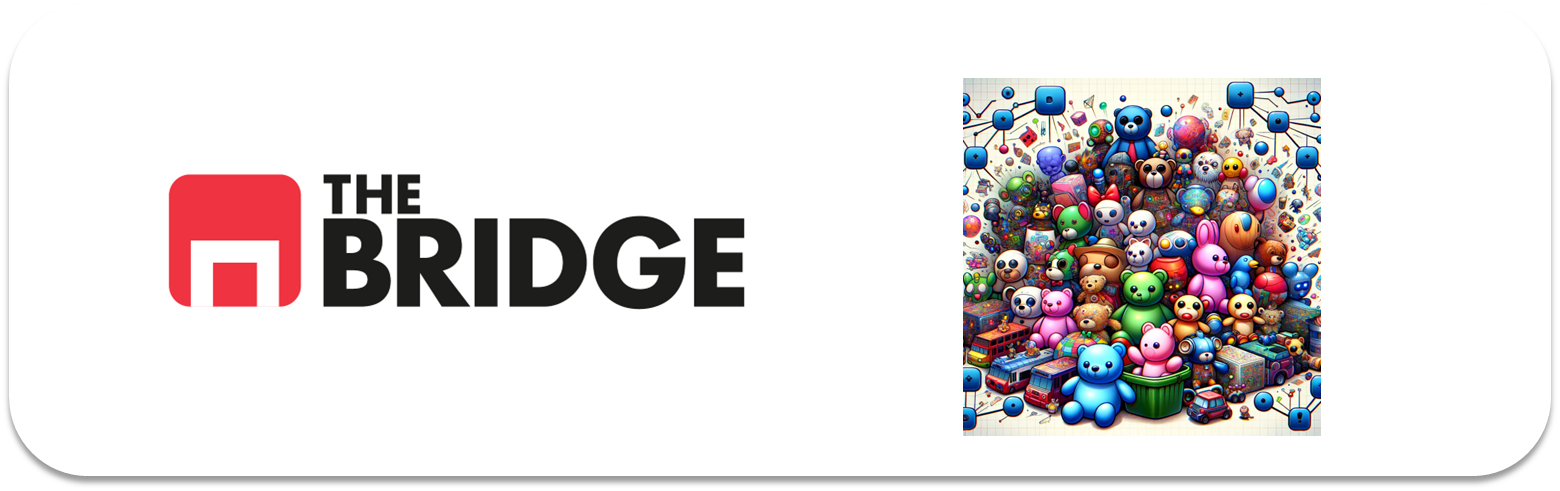

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [26]:
#Importamos paquetes y módulos habituales:

import numpy as np
import seaborn as sns
import pandas as pd

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

#Cargamos también la herramienta:
import bootcampviztools as bp

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesidad de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es especulativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [4]:
#Cargamos el dataset:
df=pd.read_csv("./data/empowering_drinks.csv", sep ="|")

In [8]:
#Visualizamos los 10 primeros valores_
df.head(10)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
5,1.716255,0.305159,0.492677,1.729520,0.083015
6,1.308617,0.890014,0.482637,1.745442,-0.003499
7,2.259772,-0.718336,0.954502,0.949319,0.061386
8,1.061565,-0.352802,1.125176,0.949319,0.935177
9,1.358028,-0.243142,1.295850,2.430109,0.299300


In [9]:
#Obtenemos la descripción de las numéricas:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [16]:
df.isna().sum()

Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

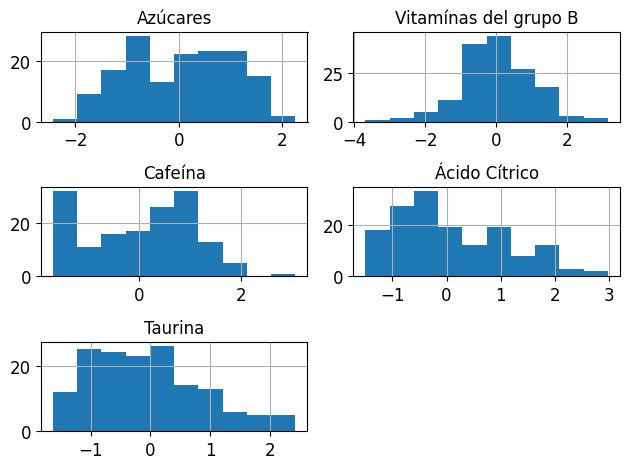

In [7]:
#Todas las columnas son numéricas. Visualizamos los histogramas:
df.hist()
plt.tight_layout()

In [35]:
features=df.columns.to_list()
features

['Azúcares', 'Vitamínas del grupo B', 'Cafeína', 'Ácido Cítrico', 'Taurina']

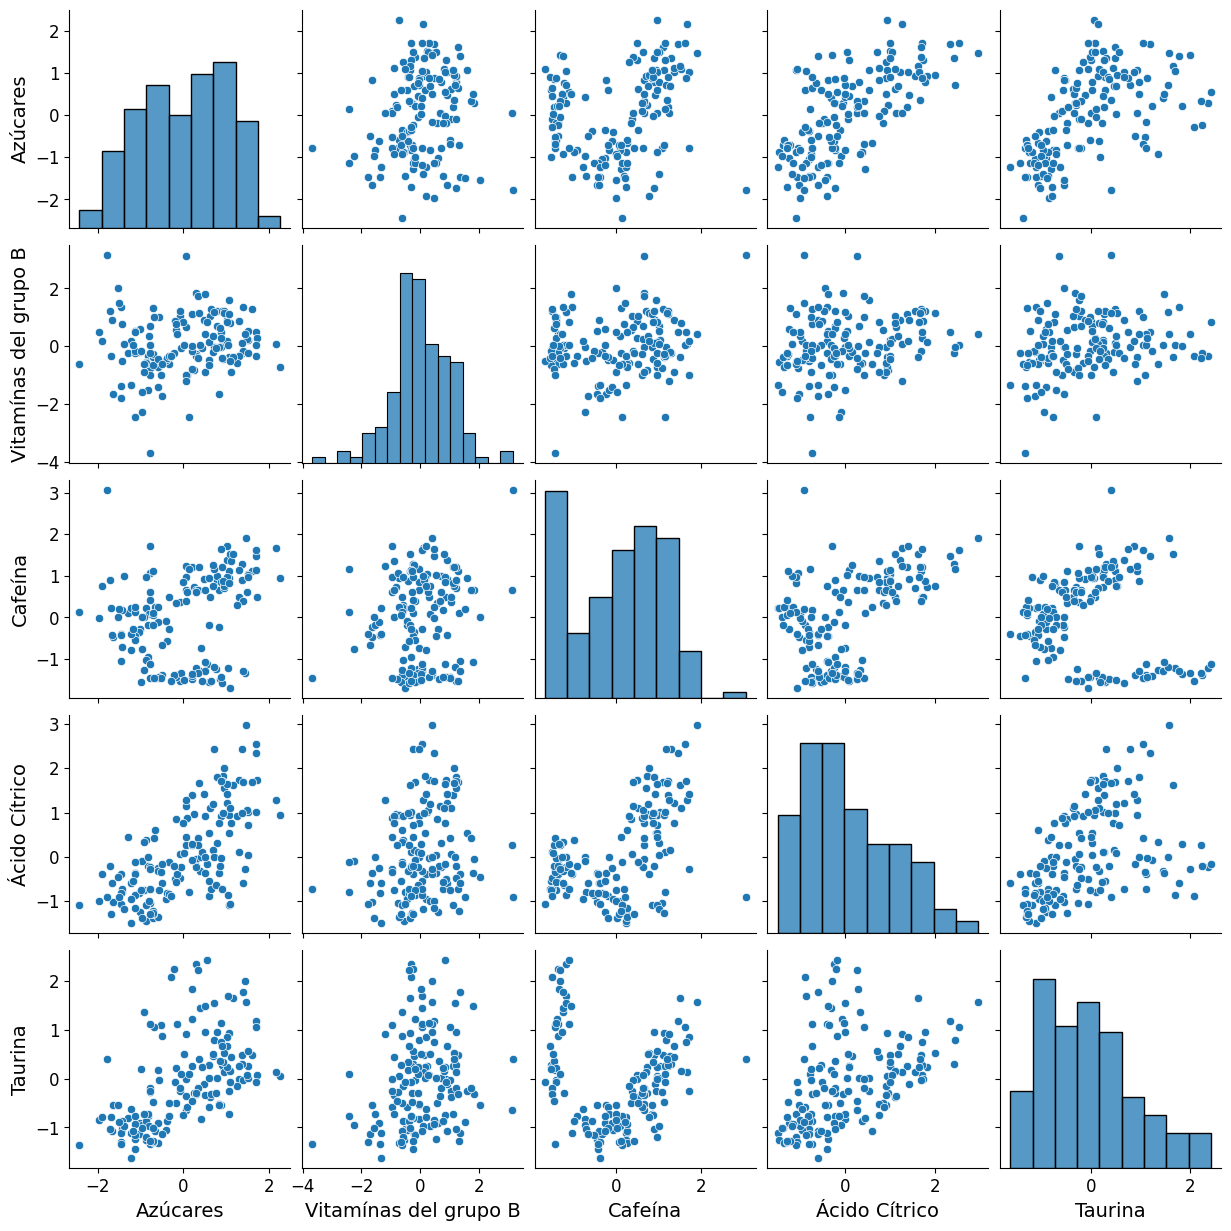

In [14]:
#Visualizamos los emparejamientos:
sns.pairplot(df)
plt.show()

In [36]:
#Nos cargamos la vitamina B:
features.remove("Vitamínas del grupo B")

In [38]:
features

['Azúcares', 'Cafeína', 'Ácido Cítrico', 'Taurina']

In [39]:
from sklearn.preprocessing import StandardScaler

escalador= StandardScaler()

X= escalador.fit_transform(df[features])

In [44]:
#Pasamos el array a DataFrame:
X_df=pd.DataFrame(X, columns=features)

In [46]:
X_df

,Azúcares,Cafeína,Ácido Cítrico,Taurina
0,1.465925,0.957824,0.927289,0.317612
1,0.221992,0.667526,0.879813,-0.267608
2,0.173684,1.132002,1.307094,0.336190
3,1.635003,1.373917,2.240782,1.320844
4,0.270301,0.599790,-0.117176,-0.295475
...,...,...,...,...
148,0.463533,-1.277470,-0.069700,1.088614
149,0.306532,-1.335530,0.199329,2.435547
150,0.185761,-1.345206,0.215154,2.017534
151,1.345155,-1.267793,-0.671058,1.971088


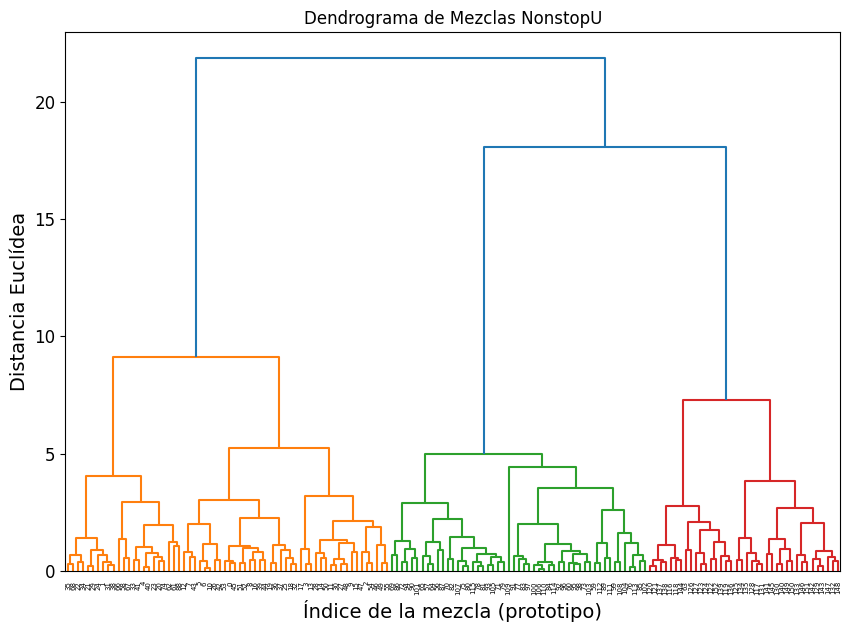

In [47]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 7))
plt.title("Dendrograma de Mezclas NonstopU")
# Usamos el método 'ward' que minimiza la varianza dentro de los clusters
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.xlabel("Índice de la mezcla (prototipo)")
plt.ylabel("Distancia Euclídea")
plt.show()

In [48]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

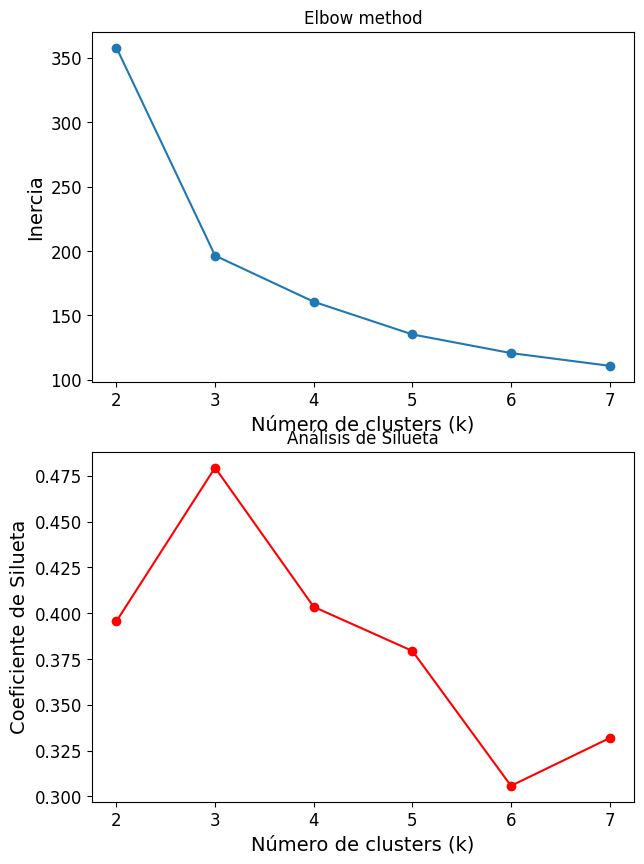

<Figure size 640x480 with 0 Axes>

In [76]:
#Ajustamos con k-MEANS:
# Probamos con varios k para justificar nuestra elección
inercias = []
siluetas=[]
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=km.fit_predict(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10))

ax1.plot(range(2, 8), inercias, marker='o')
ax1.set_title("Elbow method")
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia")

ax2.plot(range(2, 8), siluetas, marker='o', color='r')
ax2.set_title('Análisis de Silueta')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Coeficiente de Silueta')

plt.show()
plt.tight_layout()

In [77]:
#EL CLUSTER ÓPTIMO ES K=4 en caso de K-MEANS

In [78]:
#Cargamos el mejor modelo de kMeans
km_best = KMeans(n_clusters=4, random_state=42, n_init=10)
km_best.fit_predict(X)

array([1, 3, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3,
       3, 3, 1, 3, 1, 1, 1, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 3, 0, 0, 3, 3, 3, 0, 0,
       3, 3, 3, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [79]:
X_df["cluster_Kmeans"]=km_best.fit_predict(X)

In [81]:
X_df.cluster_Kmeans.value_counts()

cluster_Kmeans
0    49
2    37
1    36
3    31
Name: count, dtype: int64

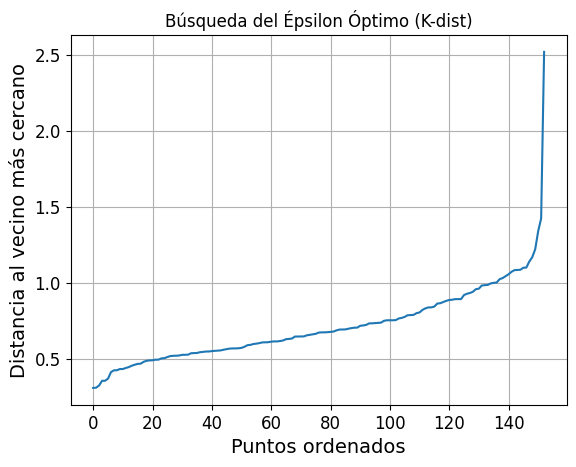

In [61]:
#Antes de nada calculamos las distancias entre puntos:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

#Ordenamos las distancias:
distances = np.sort(distances[:, 4], axis=0)

plt.plot(distances)
plt.title('Búsqueda del Épsilon Óptimo (K-dist)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al vecino más cercano')
plt.grid(True)

In [64]:
#Ajustamos con DBSCAN:

dbs= DBSCAN(eps=1.0, min_samples=6)
dbs.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1.0
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",6
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [82]:
dbs.labels_

array([ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  1,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [66]:
# Ver cuántos clusters ha encontrado (excluyendo el ruido)
n_clusters_ = len(set(dbs.labels_)) - (1 if -1 in dbs.labels_ else 0)
print(f'Número de clusters encontrados: {n_clusters_}')

# Ver cuántos puntos son ruido
n_noise_ = list(dbs.labels_).count(-1)
print(f'Número de puntos de ruido: {n_noise_}')

Número de clusters encontrados: 2
Número de puntos de ruido: 6


In [87]:
X_df.value_counts()

Azúcares   Cafeína    Ácido Cítrico  Taurina    cluster_Kmeans
-2.398720   0.096607  -1.155310      -1.419467  0                 1
-1.939793  -0.058219  -1.069854      -0.871405  0                 1
-1.891485   0.696556  -0.465330      -0.792447  0                 1
-1.758638   2.912496  -0.971737       0.484817  3                 1
-1.698253   0.822351  -0.291253      -1.071123  0                 1
                                                                 ..
 1.647080   1.064266   0.927289      -0.026089  1                 1
            1.519066   2.452840       1.181506  1                 1
 1.659157   0.435287   1.639423       0.136472  1                 1
 2.093930   1.567449   1.196317       0.206141  1                 1
 2.190546   0.880411   0.863988       0.113249  1                 1
Name: count, Length: 153, dtype: int64

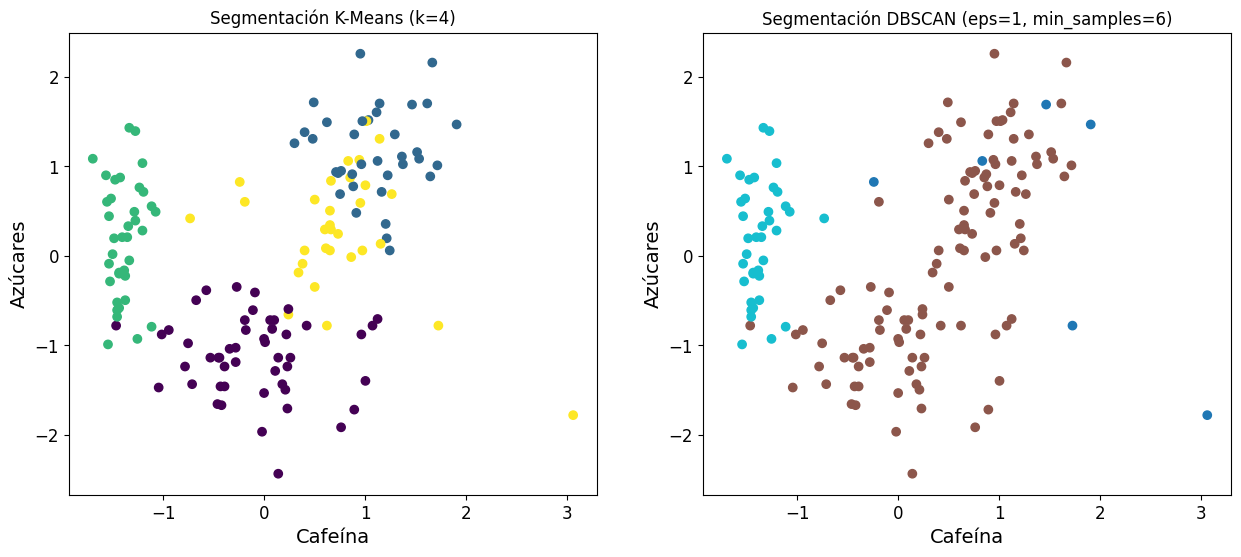

In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Visualización K-Means (Suponiendo que usaste k=4)
# Sustituye 'cluster_kmeans' por el nombre de tu columna de resultados
ax1.scatter(df['Cafeína'], df['Azúcares'], c=X_df['cluster_Kmeans'], cmap='viridis')
ax1.set_title('Segmentación K-Means (k=4)')
ax1.set_xlabel('Cafeína')
ax1.set_ylabel('Azúcares')

# Visualización DBSCAN
# El color -1 (outliers) suele salir en un color distinto (ej. negro)
ax2.scatter(df['Cafeína'], df['Azúcares'], c=dbs.labels_, cmap='tab10')
ax2.set_title('Segmentación DBSCAN (eps=1, min_samples=6)')
ax2.set_xlabel('Cafeína')
ax2.set_ylabel('Azúcares')

plt.show()

#### Conclusiones

La comparación es especulativa porque no existe una "verdad absoluta" (etiquetas). K-Means asume que los grupos tienen forma esférica y tamaño similar, mientras que DBSCAN busca zonas densas de cualquier forma. Que DBSCAN vea 2 grupos y los químicos esperen 4 sugiere que algunos de esos 4 grupos están tan cerca entre sí que, a ojos de la densidad, parecen uno sol

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [94]:
nuevos=pd.read_csv("./data/new_experiments.csv", sep="|")

In [96]:
X_new=nuevos[features]

In [97]:
X_new

,Azúcares,Cafeína,Ácido Cítrico,Taurina
0,1.481555,1.366128,2.239039,0.731870
1,0.616869,0.583034,0.312420,-0.665332
2,-1.680724,-0.340615,-0.213021,-0.976782
3,-0.284874,-0.782361,-1.193845,-0.717240
4,-0.927212,-1.565455,-0.085641,-0.522583
5,0.962743,-1.354622,-0.420013,1.956043


In [98]:
X_new_scaled = escalador.transform(X_new)

In [ ]:
#Función que te dibuja los centroides:
def plot_centroids(centroids, weights=None, circle_color='w', cross_color='b'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=15, linewidths=20,
                color=cross_color, zorder=11, alpha=1)

In [109]:
def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

In [107]:
centroides = km_best.cluster_centers_
print("Forma de los centroides:", centroides.shape)

Forma de los centroides: (4, 4)


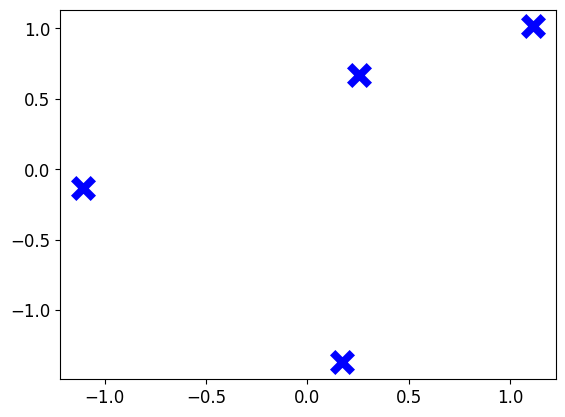

In [108]:
#Dibujamos los centroides de k-means
plot_centroids(centroides)

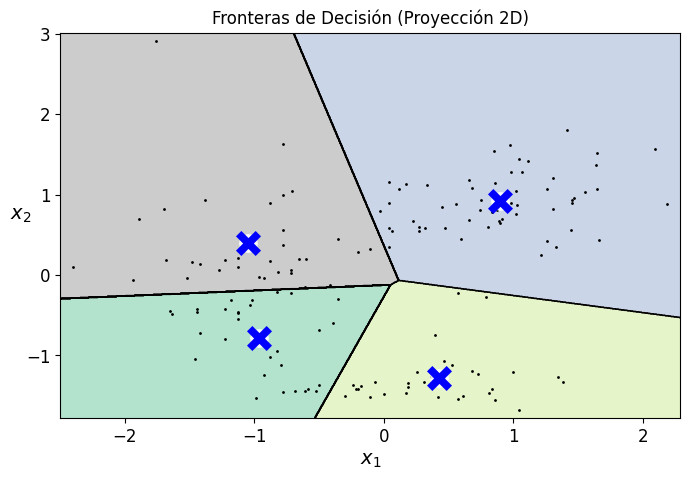

In [ ]:
#Dibujamos los puntos
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

#Creamos un dataset de solo 2 columnas para el gráfico
X_plot = X_df.values[:, :2]

#Entrenamos un modelo rápido con el mismo número de clusters que tu km_best
km_canvas = KMeans(n_clusters=km_best.n_clusters, random_state=42)
km_canvas.fit(X_plot)

#Ejecutamos la función con este modelo "visual"
plt.figure(figsize=(8, 5))
plot_decision_boundaries(km_canvas, X_plot)
plt.title("Fronteras de Decisión (Proyección 2D)")
plt.show()

In [ ]:
#Utilizamos K-means para hacer las predicciones
predicciones=km_best.predict(X_new_scaled) #k=4, 

In [114]:
predicciones

array([1, 3, 0, 0, 0, 2], dtype=int32)

In [116]:
nuevos["etiqueta"]=predicciones

In [117]:
nuevos

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,etiqueta
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,3
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,0
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,0
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,0
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


In [118]:
#HAcemos el test de silueta para los nuevos datos:
score_nuevos = silhouette_score(X_new_scaled, nuevos["etiqueta"])
print(f"Coeficiente de Silueta para nuevos experimentos: {score_nuevos:.2f}")

Coeficiente de Silueta para nuevos experimentos: 0.17


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.